## FOOD ORDERING DATA ANALYSIS USING PYTHON

## PROBLEM STATEMENT
The objective of this project is to analyze food ordering data across multiple tech parks to understand customer behavior, sales performance, and revenue patterns.

The analysis focuses on identifying key trends such as peak ordering times, top-performing items, revenue contribution by location, and customer purchasing behavior to enable data-driven business decisions.

## DATA DESCRIPTION
The dataset contains transactional data of food orders including:

- Order ID: Unique identifier for each order  
- Employee ID: Customer identifier  
- Restaurant: Source of food  
- Item: Ordered product  
- Price: Cost of item  
- Rating: Customer rating  
- Shift: Time of order (Lunch, Dinner, Snacks)  
- Tech Park: Location of order  
- Date: Order date  

## LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_excel(r"C:\Users\aayus\Desktop\sql_vendmat_analysis.xlsx")

In [3]:
df.head()

,Order_ID,Employee_ID,Employee_Name,Restaurant,Item,Shift,Order_Time,Date,Rating,Price,Tech_Park
0,1,EP3063,A. Amitha,Protein Chef,High Protein Bread Omelette,Lunch,12:35,2024-10-01,4.0,120,ITPL Whitefield
1,2,EP3086,A. Deepika,Protein Chef,High Protein Sandwich,Lunch,12:40,2024-10-01,3.0,150,ITPL Whitefield
2,3,EP2042,Sai,Mumma's Kitchen,Rajma Rice Combo,Lunch,12:53,2024-10-01,2.0,130,EcoWorld Bellandur
3,4,EP3095,Yash Das,Rise and Dine,Paneer Biryani,Lunch,13:14,2024-10-01,NaN,160,ITPL Whitefield
4,5,EP2042,Sai,Mumma's Kitchen,Dal Rice Combo,Lunch,13:24,2024-10-01,5.0,120,EcoWorld Bellandur


## BASIC CHECK

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11516 entries, 0 to 11515
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       11516 non-null  int64         
 1   employee_id    11516 non-null  object        
 2   employee_name  11516 non-null  object        
 3   restaurant     11516 non-null  object        
 4   item           11516 non-null  object        
 5   shift          11516 non-null  object        
 6   order_time     11516 non-null  object        
 7   date           11516 non-null  datetime64[ns]
 8   rating         10916 non-null  float64       
 9   price          11516 non-null  int64         
 10  tech_park      11516 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 989.8+ KB


order_id           0
employee_id        0
employee_name      0
restaurant         0
item               0
shift              0
order_time         0
date               0
rating           600
price              0
tech_park          0
dtype: int64

In [6]:
df.dtypes

order_id                  int64
employee_id              object
employee_name            object
restaurant               object
item                     object
shift                    object
order_time               object
date             datetime64[ns]
rating                  float64
price                     int64
tech_park                object
dtype: object

## DATA CLEANING
- Handled missing values in rating column using mean imputation  
- Verified that no duplicate records exist in the dataset  
- Standardized column names to lowercase for consistency
- Verified that no abnormal or inconsistent data exists in the dataset

In [7]:
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [8]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.columns = df.columns.str.lower()

In [9]:
df[df['price'] < 0]
df[df['rating'] > 5]

,order_id,employee_id,employee_name,restaurant,item,shift,order_time,date,rating,price,tech_park


## FEATURE ENGINEERING
- Extracted day of the week and months from the date column  


In [10]:
df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()

In [11]:
df.head()

,order_id,employee_id,employee_name,restaurant,item,shift,order_time,date,rating,price,tech_park,day,month
0,1,EP3063,A. Amitha,Protein Chef,High Protein Bread Omelette,Lunch,12:35,2024-10-01,4.000000,120,ITPL Whitefield,Tuesday,October
1,2,EP3086,A. Deepika,Protein Chef,High Protein Sandwich,Lunch,12:40,2024-10-01,3.000000,150,ITPL Whitefield,Tuesday,October
2,3,EP2042,Sai,Mumma's Kitchen,Rajma Rice Combo,Lunch,12:53,2024-10-01,2.000000,130,EcoWorld Bellandur,Tuesday,October
3,4,EP3095,Yash Das,Rise and Dine,Paneer Biryani,Lunch,13:14,2024-10-01,3.315042,160,ITPL Whitefield,Tuesday,October
4,5,EP2042,Sai,Mumma's Kitchen,Dal Rice Combo,Lunch,13:24,2024-10-01,5.000000,120,EcoWorld Bellandur,Tuesday,October


## ANALYSIS
- Calculated total orders, total revenue, and average order value (AOV)  
- Analyzed orders and revenue by tech park  
- Evaluated order distribution across shifts and days of the week  
- Identified top-selling and highest revenue-generating items  
- Computed revenue contribution (%) by each tech park  
- Identified repeat customers and their impact  
- Analyzed top-performing items within each tech park  

In [12]:
total_orders = len(df)

In [13]:
total_orders

11516

In [14]:
total_revenue = df['price'].sum()

In [15]:
total_revenue

np.int64(1318725)

In [16]:
avg_rating = round(df['rating'].mean(), 2)

In [17]:
avg_rating

np.float64(3.32)

In [18]:
# Orders by shift
df['shift'].value_counts()

shift
Lunch     4521
Dinner    3635
Snacks    3360
Name: count, dtype: int64

In [31]:
# orders by tech_parl
orders_tp = df['tech_park'].value_counts().reset_index()
orders_tp.columns = ['tech_park', 'total_orders']
orders_tp

,tech_park,total_orders
0,RMZ Azure Hebbal,4035
1,EcoWorld Bellandur,3751
2,ITPL Whitefield,3730


In [20]:
# Revenue by tech park
rev = df.groupby('tech_park')['price'].sum().sort_values(ascending = False)

In [36]:
rev_contribution = (rev / rev.sum()) * 100

In [46]:
# Orders by day
df['day'].value_counts()

day
Friday       3408
Thursday     2613
Tuesday      2232
Wednesday    2189
Monday       1074
Name: count, dtype: int64

In [47]:
# Top items
df['item'].value_counts().head(10)

item
Bread Omelette                    610
Dal Rice Combo                    594
Paneer Biryani                    593
High Protein Sahi Paneer Bowl     588
Aloo Paratha with Curry           588
High Protein Sandwich             583
Egg Puff                          582
Samosa                            581
High Protein Chicken Rice Bowl    580
Veg Puff                          562
Name: count, dtype: int64

In [54]:
# Revenue by item
df.groupby('item')['price'].sum().sort_values(ascending=False).head(10)

item
High Protein Chicken Rice Bowl    116000
High Protein Sahi Paneer Bowl     105840
Paneer Biryani                     94880
High Protein Sandwich              87450
Veg Biryani                        75740
Chicken Meal Deluxe Bento          75400
Dal Rice Combo                     71280
Rajma Rice Combo                   70200
High Protein Bread Omelette        67200
Palak Paneer Rice Bowl             66600
Name: price, dtype: int64

In [55]:
# Restaurant performance
df.groupby('restaurant')['price'].sum().sort_values(ascending=False)

restaurant
Protein Chef       376490
Grab a Bite        363510
Mumma's Kitchen    261880
Rise and Dine      234620
Cafe                82225
Name: price, dtype: int64

In [56]:
# Repeat customers
df['employee_id'].value_counts().head(10)

employee_id
EP1023    72
EP1092    63
EP3029    61
EP3042    58
EP1006    57
EP3054    57
EP2028    56
EP2025    56
EP2073    55
EP3091    54
Name: count, dtype: int64

In [57]:
# High vs low revenue items
item_rev = df.groupby('item')['price'].sum()
item_rev[item_rev > item_rev.mean()]

item
3CP Chicken Bento                  63180
Chicken Meal Deluxe Bento          75400
Dal Rice Combo                     71280
High Protein Bread Omelette        67200
High Protein Chicken Rice Bowl    116000
High Protein Sahi Paneer Bowl     105840
High Protein Sandwich              87450
Mixed Veg Paratha Combo            61600
Palak Paneer Rice Bowl             66600
Paneer Biryani                     94880
Rajma Rice Combo                   70200
Veg Biryani                        75740
Name: price, dtype: int64

In [53]:
# Top items in each tech park
top_item_tech_park_analysis =df.groupby(['tech_park', 'item'])['price'].sum().sort_values(ascending = False).groupby('tech_park').head(1)
top_item_tech_park_analysis

tech_park           item                          
RMZ Azure Hebbal    High Protein Chicken Rice Bowl    42800
EcoWorld Bellandur  High Protein Chicken Rice Bowl    37400
ITPL Whitefield     High Protein Chicken Rice Bowl    35800
Name: price, dtype: int64

In [55]:
# Low revenue generating items in each tech park
low_item_tech_park_analysis =df.groupby(['tech_park', 'item'])['price'].sum().sort_values(ascending = False).groupby('tech_park').tail(1)
low_item_tech_park_analysis

tech_park           item  
RMZ Azure Hebbal    Samosa    5200
ITPL Whitefield     Samosa    4775
EcoWorld Bellandur  Samosa    4550
Name: price, dtype: int64

## VISUALIZATION

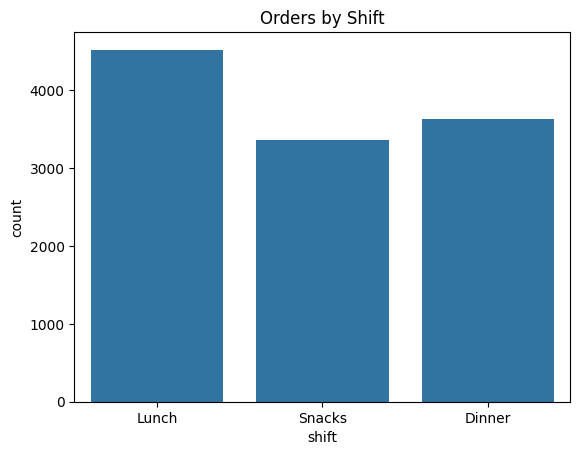

In [58]:
# Orders by shift
sns.countplot(data=df, x='shift')
plt.title("Orders by Shift")
plt.show()

Text(0, 0.5, 'Revenue')

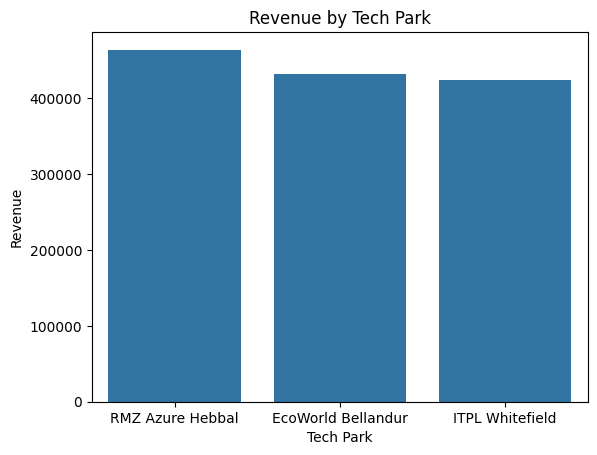

In [40]:
# orders by tech_park
sns.barplot(data=rev_df, x='tech_park', y='revenue')

plt.title("Revenue by Tech Park")
plt.xlabel("Tech Park")
plt.ylabel("Revenue")

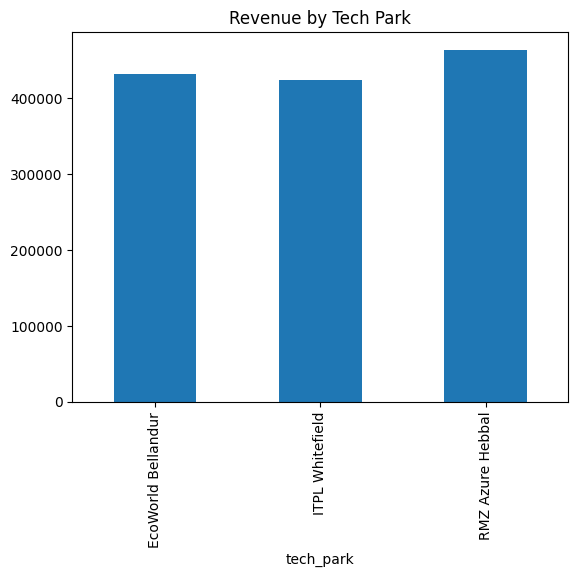

In [59]:
# Revenue by tech park
df.groupby('tech_park')['price'].sum().plot(kind='bar')
plt.title("Revenue by Tech Park")
plt.show()

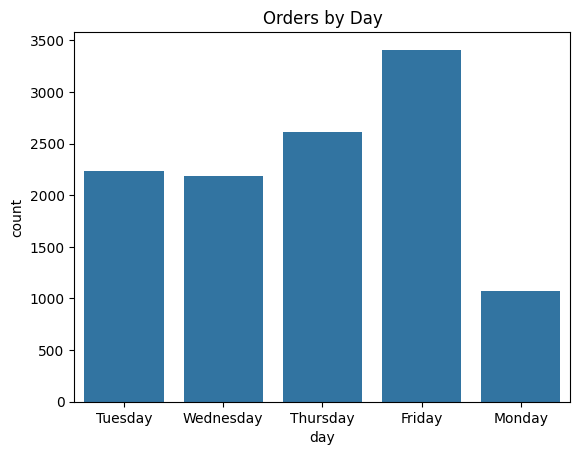

In [63]:
# Orders by day
sns.countplot(x = 'day' , data = df)
plt.title("Orders by Day")
plt.show()

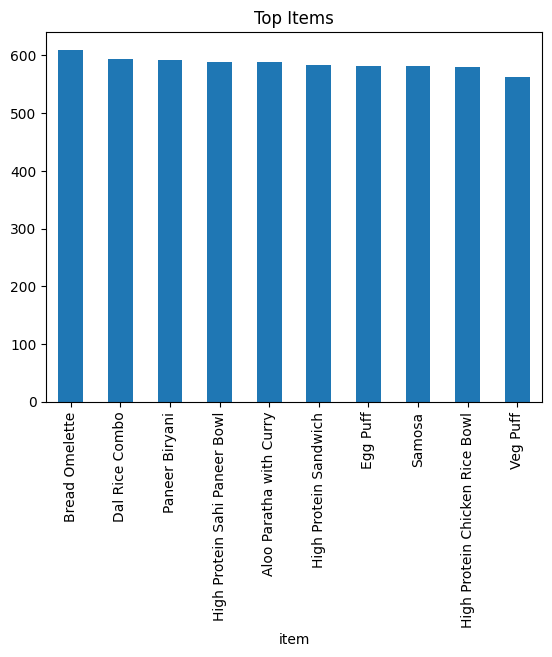

In [65]:
# Top items
df['item'].value_counts().head(10).plot(kind='bar')
plt.title("Top Items")
plt.show()

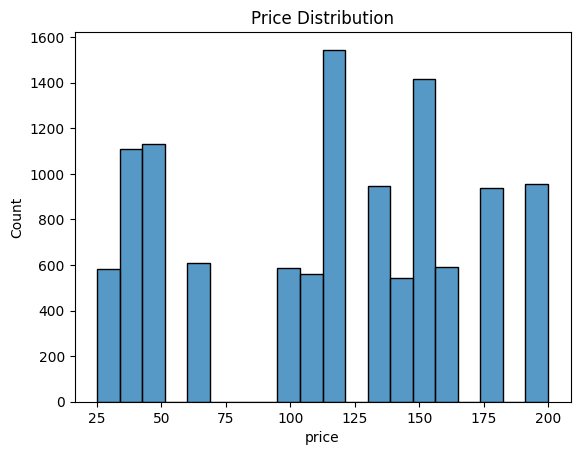

In [67]:
# Revenue distribution
sns.histplot(df['price'], bins=20)
plt.title("Price Distribution")
plt.show()

In [70]:
print('1. Lunch generates highest orders and revenue')
print('2. Friday is peak demand, Monday lowest')
print('3. RMZ Azure contributes highest revenue (~35%)')
print('4. High-protein items generate higher revenue despite lower frequency')
print('5. Repeat customers contribute significantly')
print('6. Pricing is consistent across tech parks')
print('7. Demand concentrated in top items')

1. Lunch generates highest orders and revenue
2. Friday is peak demand, Monday lowest
3. RMZ Azure contributes highest revenue (~35%)
4. High-protein items generate higher revenue despite lower frequency
5. Repeat customers contribute significantly
6. Pricing is consistent across tech parks
7. Demand concentrated in top items


In [74]:
print('1. Increase inventory and machine readiness during lunch hours to handle peak demand')
print('2. Run promotions or discounts on Mondays to boost low demand')
print('3. Allocate more resources and stock to RMZ Azure Hebbal as it drives highest revenue')
print('4. Promote high-protein items more aggressively to maximize revenue')
print('5. Introduce loyalty programs to retain repeat customers')
print('6. Maintain consistent pricing strategy across tech parks while testing premium pricing for high-demand items')
print('7. Focus on top-performing items and optimize menu by removing low-performing ones')

1. Increase inventory and machine readiness during lunch hours to handle peak demand
2. Run promotions or discounts on Mondays to boost low demand
3. Allocate more resources and stock to RMZ Azure Hebbal as it drives highest revenue
4. Promote high-protein items more aggressively to maximize revenue
5. Introduce loyalty programs to retain repeat customers
6. Maintain consistent pricing strategy across tech parks while testing premium pricing for high-demand items
7. Focus on top-performing items and optimize menu by removing low-performing ones
